# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

Answers:
1. A model is linear when the predicted outcome is a sum of all the variables times some coefficient. This can be represented by ... . The moel is linear in its coefficients/variables.

2. The coefficient for a dummy/hot-encoding represents the difference between the "dropped" baseline variable to the reference category.The incercept is the predicted value for that reference category.

3.It is not recommended because it predicts values outside the propability range and faisl to handle non linear decision boundaries

4.Little training, unstable coefficient, the model is memorizing its data

5. mutlicollinearity haooens when two or more variables are higlhy correlated and expali nthe ame variation in the outcome variable. Using the two stage idea, we can understanf this more clearly. In the first stage, we take the variable x and regress both the outcome variable y and x on all other varaibles in the model, keeping the residuals. These residuals repreasent parts of y and x that are not represented by the other varaibles.In the second srage, we regress the residuals of y on the residuals of x and it gives us the same slope coefficient as in the full regression.
6.Nonlineat relationships between x and y can be added into a linear regression by translating the independent variables.In addition we can add them as interation variables .THese transformations allow a linear model to capture nonlinear patterns.
7.The slope coefficient in a linear regression is the expected increase/decrease in the outcome variable for a one unit increase in the independent variables such as x. It essentially measures the relationship between the independent variables and the outcome variable for the influence of other variables in the model.
8.A train and test split divides the data into a training set and testign set. The model will be traiend using the patters on the trainign set and evaluated usign the testing set. This is the most common method to yse.In kfold cross validation the data is divided into k parts and repeatedly trained and the model is tested using different folds.This provides more reliable and stable estimates.

9. the number of k-fold is choosem up to 10 to balance reliable performance esimates with computational efficiency.

In [1]:
! git clone https://github.com/SafaaMahbub/undergrad_ml_assignments
%run ./undergrad_ml_assignments/get_data.py

Cloning into 'undergrad_ml_assignments'...
remote: Enumerating objects: 184, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 184 (delta 70), reused 32 (delta 32), pack-reused 101 (from 2)
Receiving objects: 100% (184/184), 16.40 MiB | 16.35 MiB/s, done.
Resolving deltas: 100% (84/84), done.
Download complete
Extracting data files...
Data extracted


**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_csv('./data/airbnb_hw.csv')
df.head()

df['Price']=pd.to_numeric(df['Price'],errors='coerce')
df['Review Scores Rating']=pd.to_numeric(df['Review Scores Rating'],errors='coerce')
neighbourGroups_means = df.groupby('Neighbourhood ')['Price'].mean()
print(neighbourGroups_means);

Neighbourhood 
Bronx             83.308140
Brooklyn         124.595122
Manhattan        183.964571
Queens           100.012747
Staten Island    111.312500
Name: Price, dtype: float64


Manhatteb is the most expensive on average.

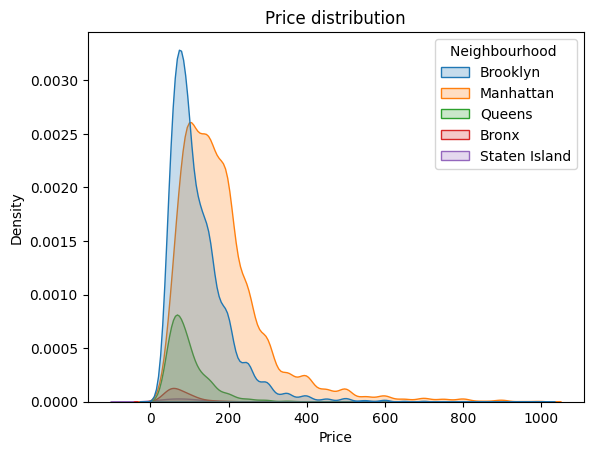

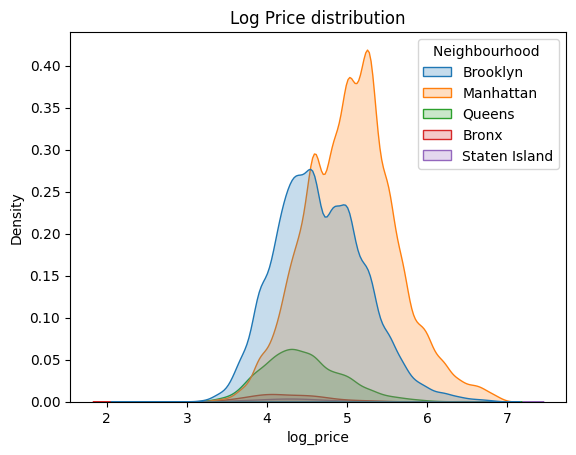

In [ ]:
df['log_price'] = np.log(df['Price'])
sns.kdeplot(data=df, x='Price', hue='Neighbourhood ', fill=True)
plt.title("Price distribution")
plt.show()

sns.kdeplot(data=df, x='log_price', hue='Neighbourhood ', fill=True)
plt.title("Log Price distribution")
plt.show()

In [ ]:
tdf = df.loc[:, ['Price', 'Neighbourhood ']].dropna()
y = tdf['Price']
X_neigh = pd.get_dummies(tdf['Neighbourhood '],dtype ='int',drop_first=True)

model = LinearRegression()
model.fit(X_neigh, y)

print(f'Model intercept:{model.intercept_}')
pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })

Model intercept:83.3081395348837


,variable,coefficient
0,Brooklyn,41.286982
1,Manhattan,100.656432
2,Queens,16.704608
3,Staten Island,28.004360


The bronx was dropped and used as the baseline.

The intercept has similar values that equals the average price of the basline refernece point (Bronx = 83.3081).Adding the intercept to a coefficient produces the conditional group mean for that neighbourhood.

In [ ]:
tdf = df[['Price', 'Review Scores Rating']].dropna()
y = tdf['Price']
X_rating = tdf['Review Scores Rating']

model = LinearRegression()
model.fit(X_rating.values.reshape(-1, 1), y)

print(f'Model intercept:{model.intercept_}')
print(f"Model slope:{model.coef_[0]}")

Model intercept:59.404942120702586
Model slope:0.9938705552542306


on average, each increase in the REview Scores Rating is associated with an increase of about 1$ per night in price.

In [ ]:
tdf = df[['Price', 'Review Scores Rating','Neighbourhood ']].dropna()

x = pd.get_dummies(tdf['Neighbourhood '],dtype ='int',drop_first=True)

x_mix = pd.concat([x,tdf[['Review Scores Rating']]],axis =1)


y = tdf['Price']
model = LinearRegression()
model.fit(x_mix, y)


info = pd.DataFrame({'variable':model.feature_names_in_, 'coefficient':model.coef_ })



print(f'Model intercept:{model.intercept_}')
print(f"Coefficients:{info}")

Model intercept:-21.08326752107004
Coefficients:               variable  coefficient
0              Brooklyn    49.222780
1             Manhattan   103.056308
2                Queens    21.691463
3         Staten Island    20.086757
4  Review Scores Rating     1.051338


for each increase in the rating, the price of the neighbourhood per night will increase by 1.05$

In [ ]:
tdf = df[['Price', 'Review Scores Rating','Neighbourhood ']].dropna()

dummies = pd.get_dummies(tdf['Neighbourhood '],dtype ='int',drop_first=True)
#multiply rating scores by each neighbourhod dummy to seperate slopes
x= dummies.mul(tdf['Review Scores Rating'],axis=0)
x['intercept'] = 1

y = tdf['Price']
model = LinearRegression(fit_intercept=False)
model.fit(x, y)

slopes_df = pd.DataFrame({'borough':model.feature_names_in_, 'slopes':model.coef_ }).sort_values(by='slopes')

print(slopes_df)

         borough     slopes
3  Staten Island   0.327540
2         Queens   0.348597
0       Brooklyn   0.655266
1      Manhattan   1.233831
4      intercept  65.107491


In [ ]:
the slopes are not the same across the boroughs and Manhatten seeems to have much more sensitivity for the ratings than the pther neighbourhoods such as Queems.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

df = pd.read_csv('./data/cars_hw.csv')
df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [ ]:
df['Price']=pd.to_numeric(df['Price'],errors='coerce')

In [ ]:
df['Price'].describe()

,Price
count,9.760000e+02
mean,7.410195e+05
std,3.673234e+05
min,1.880000e+05
25%,4.757500e+05
50%,6.665000e+05
75%,8.830000e+05
max,2.941000e+06


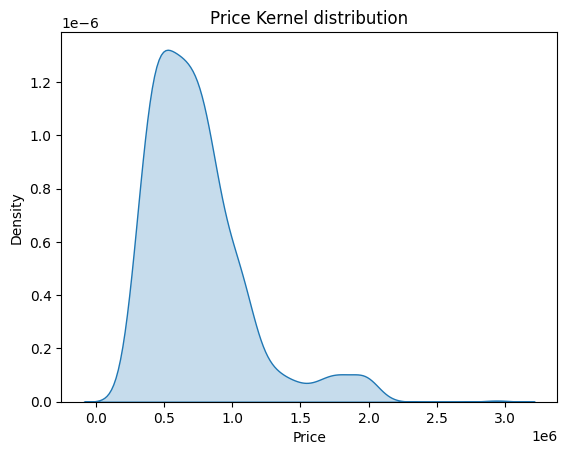

In [ ]:
sns.kdeplot(data=df, x='Price', fill=True)
plt.title("Price Kernel distribution")
plt.show()

In [ ]:
df.groupby('Body_Type')['Price'].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


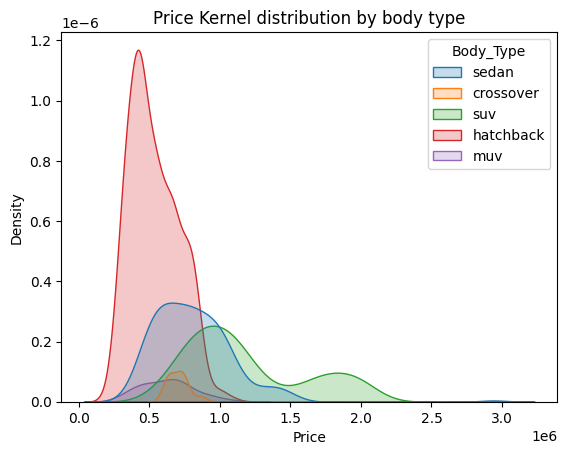

In [ ]:
sns.kdeplot(data=df, x='Price', hue='Body_Type', fill=True)
plt.title("Price Kernel distribution by body type")
plt.show()

hatchbacks have the highest density

In [ ]:
from sklearn.linear_model import LinearRegression
tdf = df[['Price', 'Seating_Capacity']].dropna()
y = tdf['Price']
X_capacity = tdf[['Seating_Capacity']]

model = LinearRegression()
model.fit(X_capacity, y)

print(f"Model slope:{model.coef_[0]}")
print(f'Model intercept:{model.intercept_}')

Model slope:59267.99803672175
Model intercept:439032.0141018266


In [ ]:
from sklearn.linear_model import LinearRegression
tdf = df[['Price', 'Seating_Capacity']].dropna()
y = tdf['Price']
X_capacity = pd.get_dummies(tdf['Seating_Capacity'],dtype ='int')

model = LinearRegression()
model.fit(X_capacity, y)

results = pd.DataFrame({'variable':X_capacity.columns, 'coefficient':model.coef_ })
print(f"Model slope:{model.coef_[0]}")
print(f'Model intercept:{model.intercept_}')

Model slope:-602046.517783293
Model intercept:790046.5177832928


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
import numpy as np
df['car_age']= 2026-df['Make_Year']
tdf = df[['Price', 'car_age']].dropna()
y = tdf['Price']
x=  tdf[['car_age']]

#Tool: Chaptgpt helped me code this

for degree in range(1, 6):
    poly = PolynomialFeatures(degree=degree)
    X_poly = poly.fit_transform(x)
    model = LinearRegression()
    scores = cross_val_score(model, X_poly, y, cv=10,scoring='neg_mean_squared_error')

    print(f"Degree {degree}: MSE = {np.mean(-scores)}")



Degree 1: MSE = 100295370079.4554
Degree 2: MSE = 100814620596.42154
Degree 3: MSE = 100380163091.91774
Degree 4: MSE = 100474431121.10178
Degree 5: MSE = 100131346193.26462


using 10-fold cross validation, i compared regressions of price and car age with degrees from 1-5. the mode lwith degree 5 resulted with the lowest mean squared error. the optumal number of powers of age to include in the regression shoukld be 5

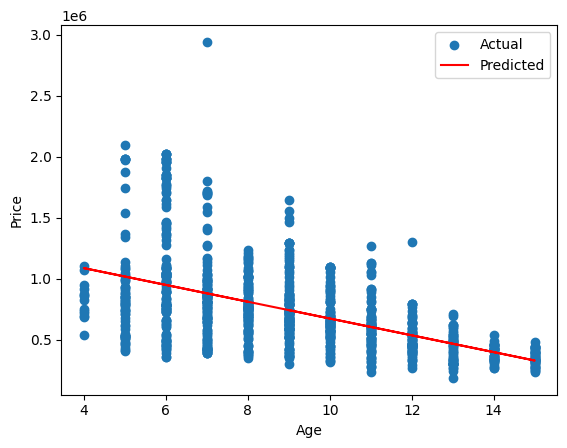

In [ ]:
from sklearn.linear_model import LinearRegression
tdf = df[['Price', 'car_age']].dropna()
y = tdf['Price']
x =  tdf[['car_age']]


model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x)

plt.scatter(x, y, label='Actual')
plt.plot(x, y_pred, color='red', label='Predicted')
plt.xlabel('Age')
plt.ylabel('Price')
plt.legend()
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [3]:
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
df = pd.read_csv('/content/heart_hw.csv')
df.head()

rate = df.groupby('transplant')['y'].mean()
print(rate)

control_rate = rate['control']
treatment_rate = rate['treatment']
ATE = treatment_rate - control_rate

print('control',control_rate,'treatment_care',treatment_rate)
print(ATE)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64
0.11764705882352941 0.34782608695652173
0.23017902813299232


the average ATE is 0.230179, meaning that receiving a heart transplant hcanges the probability by 0.23

In [13]:
df['transpant_regression'] = df['transplant'].map({'control': 0, 'treatment': 1})

In [7]:
from sklearn.linear_model import LinearRegression
tdf = df[['y', 'transpant_regression']].dropna()

X = tdf[['transpant_regression']]
y = tdf['y']

model = LinearRegression()
model.fit(X, y)

print(f"Model intercept:{model.intercept_}")
print(f"Model slope:{model.coef_[0]}")

Model intercept:0.1176470588235293
Model slope:0.23017902813299249


the results comfirm our previous calculations: the intercept is similar to the control group's average survival rate and the transplant coeffiicent is similar to the ATE.

In [8]:
#2
from sklearn.linear_model import LinearRegression
tdf = df[['y', 'transpant_regression','age']].dropna()

X = tdf[['transpant_regression','age']]
y = tdf['y']

model = LinearRegression()
model.fit(X, y)

results = pd.DataFrame({'variable':X.columns, 'coefficient':model.coef_ })

print(f"Model intercept:{model.intercept_}")
print(f"Model slope:{model.coef_[0]}")

Model intercept:0.7019569721740947
Model slope:0.2647016865036751


Regressing with age slightly increases the slopw. The intecept is the predicted probability of surviving for a control patient that is age 0(baseline). THe slope represents the increase in predicted survival probability if a patient receivesa transplant compared to a controled patient.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


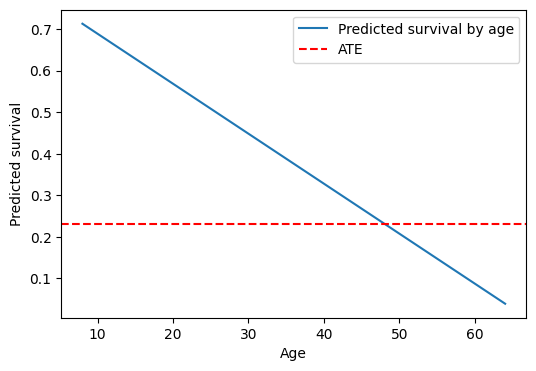

In [11]:
#3
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

age_range = np.linspace(df['age'].min(),df['age'].max(),100)

x_age= df[['age']]
y = df['y']
model = LinearRegression()
model.fit(x_age, y)

predicted = model.predict(age_range.reshape(-1, 1))

ATE = 0.23017902813299232

plt.figure(figsize=(6,4))
plt.plot(age_range, predicted, label='Predicted survival by age')
plt.axhline(y=ATE, color='r', linestyle='--', label='ATE')
plt.xlabel('Age')
plt.ylabel('Predicted survival')
plt.legend()
plt.show()

for ages 0-49 the  the impact of the transplant is underestimated by ATE and for ages 49-62 the impact of the transplant benefit overestimated it

In [20]:
#4
df['transplant_regression'] = df['transplant'].map({'control': 0, 'treatment': 1})

df= df.dropna(subset=['y','age','transplant_regression'])

df['transplant_age'] = df['transplant_regression'] * df['age']

X = df[['transplant_regression', 'age', 'transplant_age']]
y = df['y']

model = LinearRegression()
model.fit(X, y)

results = pd.DataFrame({'variable':X.columns, 'coefficient':model.coef_ })

print(f"intercept:{model.intercept_}")
print(f"Model slope:{model.coef_[0]}")

#Tool used: chatgpt helped me code this
age_range = np.linspace(df['age'].min(),df['age'].max(),100)

X_control = np.column_stack([np.zeros_like(age_range), age_range, age_range * 0])
Y_controlled = model.predict(X_control)



X_treatment = np.column_stack([np.ones_like(age_range), age_range, age_range * 1])
Y_treamtent = model.predict(X_treatment)


intercept:0.35486517529945855
Model slope:0.9077513885685898


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


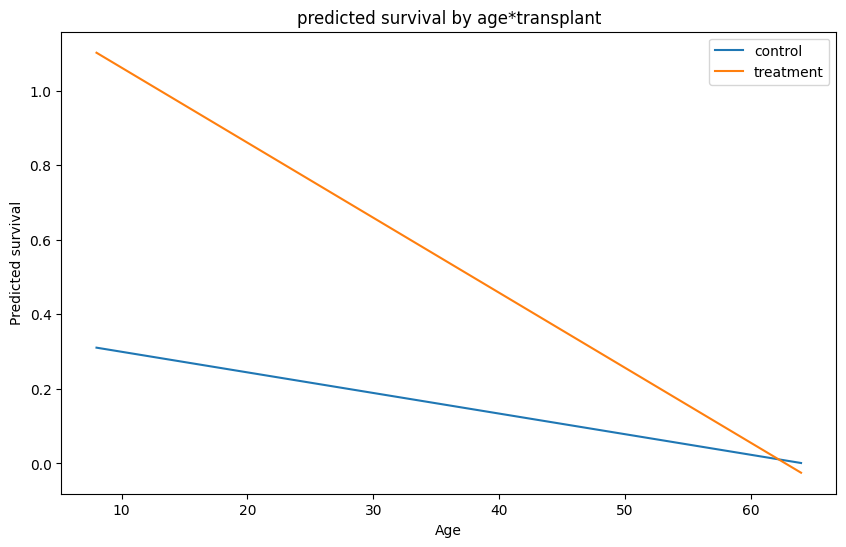

In [22]:
plt.figure(figsize=(10,6))
plt.plot(age_range, Y_controlled, label='control')
plt.plot(age_range, Y_treamtent, label='treatment')
plt.xlabel('Age')
plt.ylabel('Predicted survival')
plt.title("predicted survival by age*transplant")
plt.legend()


In [29]:
#5
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np

kfold = KFold(n_splits=10, shuffle=True, random_state=100)

X_model1 = df[['transplant_regression']]
y =df['y']
model_1 = LinearRegression()
scores_1 = cross_val_score(model_1,X_model1,y,cv =kfold,scoring='neg_mean_squared_error')
print("model 1 mean MSE", np.mean(-scores_1))

X_model2 = df[['transplant_regression','age']]
model_2 = LinearRegression()
scores_2 = cross_val_score(model_2,X_model2,y,cv =kfold,scoring='neg_mean_squared_error')

print("model 2 mean MSE", np.mean(-scores_2))

X_model3 = df[['transplant_regression','age','transplant_age']]
model_3 = LinearRegression()
scores_3 = cross_val_score(model_3,X_model3,y,cv =kfold,scoring='neg_mean_squared_error')
print("model 3 mean MSE", np.mean(-scores_3))

model 1 mean MSE 0.19366383979017968
model 2 mean MSE 0.18171967184387974
model 3 mean MSE 0.18067090272965358


Taking the age into consideration reduces the prediction error, and including the transplant*age interaction slightly decreases the error further. This alludes to the idea that a transplant depends on teh transplant ans age.

6.Age heavily influences prediction. Using this model could automatically prefer young patuents and put elder patients at a disadvantage, THe model is build based on a limited dataset and therefore the dataset could be outdated or be to small to account for the total audience.